# **Fine-Tuning Gemma2-2B with LoRA for IMDB Sentiment Classification**

This notebook demonstrates how to fine-tune the Gemma2-2B large language model for binary sentiment classification using the IMDB movie reviews dataset. To enable efficient training on limited hardware, the project employs Parameter-Efficient Fine-Tuning (PEFT) with the Low-Rank Adaptation (LoRA) technique in combination with 4-bit quantization (QLoRA), significantly reducing GPU memory consumption while training only a small fraction of the model's parameters. The notebook covers the complete workflow, including dataset loading and exploration, text preprocessing and tokenization, model quantization, LoRA configuration, supervised fine-tuning using the Hugging Face Trainer API, evaluation with standard classification metrics, and inference on unseen movie reviews. This project serves as a practical example of adapting a modern large language model to a downstream Natural Language Processing (NLP) classification task using resource-efficient fine-tuning techniques.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

## Install Required Libraries

In [2]:
%pip install \
    transformers \
    datasets \
    evaluate \
    rouge_score\
    loralib \
    bitsandbytes  \
    scikit-learn \
    peft --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 26.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## Import libraries

In [3]:
import torch
import pandas as pd
from datasets import Dataset, DatasetDict, load_dataset
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training, get_peft_model
from transformers import (
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding)

import bitsandbytes as bnb

import evaluate
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import random

 ## Authenticate with Hugging Face

In [ ]:
import huggingface_hub
hf_token = '###'
huggingface_hub.login(token=hf_token)

## Loading tokenizer

In [5]:
model_id  = "google/gemma-2b-it"
tokenizer = AutoTokenizer.from_pretrained(model_id)
print(f' Vocab size of the model {model_id}: {len(tokenizer.get_vocab())}')

config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

 Vocab size of the model google/gemma-2b-it: 256000


## Dataset loading

In [6]:
dataset = load_dataset("stanfordnlp/imdb")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [7]:
def sample_dataset(dataset, reduction_rate=0.1):
    """
    Randomly sample a subset of the train and test splits of a dataset.

    Args:
        dataset (DatasetDict): A dataset dictionary containing "train" and
            "test" splits (e.g., as returned by `load_dataset`).
        reduction_rate (float, optional): Fraction of each split to keep,
            expressed as a value between 0 and 1. Defaults to 0.1 (10%).

    Returns:
        DatasetDict: A new dataset dictionary with "train" and "test"
            splits reduced to `reduction_rate` of their original size,
            using randomly selected (non-repeating) examples.
    """
    num_train_to_keep = int(reduction_rate * dataset["train"].num_rows)
    num_test_to_keep = int(reduction_rate * dataset["test"].num_rows)

    def select_random_indices(num_rows, num_to_keep):
        return random.sample(range(num_rows), num_to_keep)

    train_indices = select_random_indices(dataset["train"].num_rows, num_train_to_keep)
    test_indices = select_random_indices(dataset["test"].num_rows, num_test_to_keep)

    return DatasetDict({
        "train": dataset["train"].select(train_indices),
        "test": dataset["test"].select(test_indices),
    })


In [8]:
def visualize_sentence_length_distribution(dataset, split="train", text_column="text"):
    """
    Visualize the distribution of sentence (text) lengths in a dataset split.

    Args:
        dataset (DatasetDict): A dataset dictionary containing splits such as
            "train" and "test" (e.g., as returned by `load_dataset`).
        split (str, optional): Which split of the dataset to visualize.
            Defaults to "train".
        text_column (str, optional): The name of the column containing the
            text/sentences whose length distribution should be plotted.
            Defaults to "text".
    """
    texts = dataset[split][text_column]
    lengths = [len(text.split()) for text in texts]

    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.histplot(lengths, bins=50, kde=True, color="steelblue", edgecolor="black")
    plt.title(f"Distribution of Sentence Lengths ({split} split)", fontsize=14, fontweight="bold")
    plt.xlabel("Sentence Length (number of words)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    sns.despine()
    plt.tight_layout()
    plt.show()


In [9]:
dataset_imdb = sample_dataset(dataset, 0.1)
print(dataset_imdb)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2500
    })
})


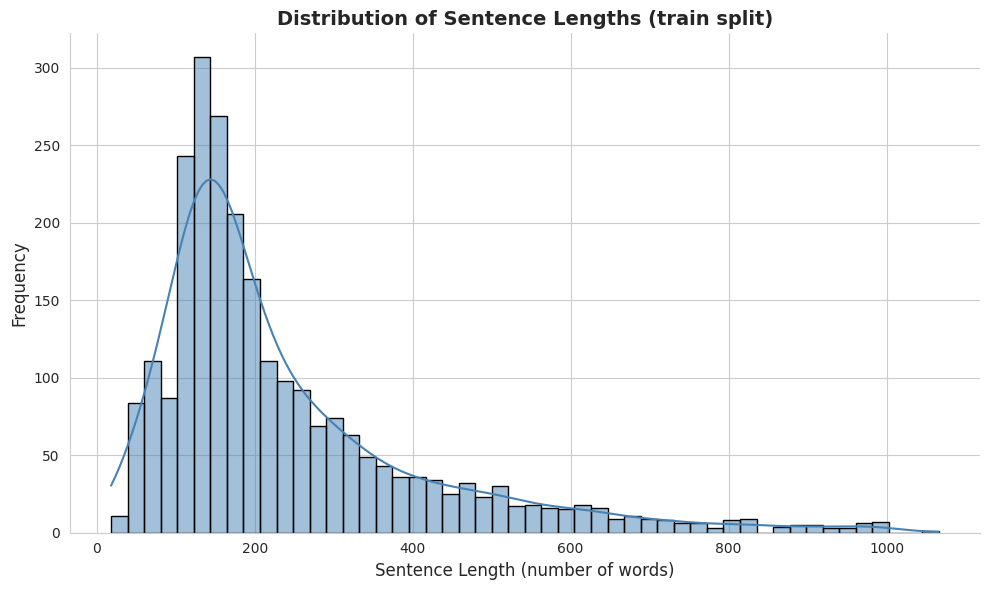

In [10]:
visualize_sentence_length_distribution(dataset_imdb)

## Tokenization

In [11]:
def tokenize_and_truncate(sample):
    return tokenizer(sample["text"], truncation=True,  max_length=512)

In [12]:
tokenized_imdb = dataset_imdb.map(tokenize_and_truncate, batched=True)

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

In [13]:
print(f"Input sample:\n\n{tokenized_imdb['train'][0]['text']}")
print(f"Tkenized input sample:\n\n{tokenized_imdb['train'][0]['input_ids']}")

Input sample:

Casting aside many of the favorable comments that have obviously come from friends and/or relatives that pepper this and many other low budget independents listed on IMDb, one is lost when it comes to using these reviews as an accurate gauge. So eventually you have to go out and rent the flick just to see for yourself. One of the first things you must understand are the catch phrases that camouflage the reality of the movie. In this case the term "dark psychological thriller." Read: "hack writer/director who thinks he's an auteur, who replaces plot, story, and action, with what he believes is a deep insight into the human soul. His great insight? Festering and repressed childhood traumas emerge to wreck havoc when we become adults. Wow, I bet Freud would be really impressed! Too many would be film makers like Kallio, who were raised on low budget horror flicks of the last few decades, fail to dig their own fresh grave. Instead, they fall into the pre-dug graves of the ma

In [14]:
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

In [15]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## Metrics

In [16]:
metric = evaluate.combine(["accuracy", "f1", "precision", "recall"])

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

## Quantization

In [17]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,  # Enables 4-bit quantization
    bnb_4bit_use_double_quant=True,  # Use double quantization for potentially higher accuracy (optional)
    bnb_4bit_quant_type="nf4",  # Quantization type (specifics depend on hardware and library)
    bnb_4bit_compute_dtype=torch.bfloat16  # Compute dtype for improved efficiency (optional)
)

## Loading the model

In [18]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_id,  # "google/gemma-2b-it"
    num_labels=2,  # Number of output labels (2 for binary sentiment classification)
    id2label=id2label,  # {0: "NEGATIVE", 1: "POSITIVE"}
    label2id=label2id,  # {"NEGATIVE": 0, "POSITIVE": 1}
    quantization_config=bnb_config,  # configuration for quantization
)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

GemmaForSequenceClassification LOAD REPORT from: google/gemma-2b-it
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Preparing for QLoRA

In [19]:
model = prepare_model_for_kbit_training(model)

In [20]:
lora_config = LoraConfig(
    r=64,  # Reduction factor (lower r means more parameters in the adapter)
    lora_alpha=32,  # Dimensionality of the adapter projection
    target_modules= ['up_proj', 'q_proj', 'k_proj', 'gate_proj',
                     'down_proj', 'o_proj', 'v_proj'],  # List of modules to apply the LoRA adapter
    lora_dropout=0.05,  # Dropout rate for the adapter
    bias="none",  # Bias configuration for the adapter
    task_type="SEQ_CLS"  # Task type (sequence classification in this case)
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 78,450,688 || all params: 2,584,627,200 || trainable%: 3.0353


## Training

In [21]:
training_args = TrainingArguments(
    output_dir="epoch_weights",          # Output directory for checkpoints
    learning_rate=2e-5,                  # Learning rate for the optimizer
    per_device_train_batch_size=1,       # Batch size per device
    per_device_eval_batch_size=1,        # Batch size per device for evaluation
    num_train_epochs=5,                  # Number of training epochs
    weight_decay=0.01,                   # Weight decay for regularization
    eval_strategy='epoch',               # Evaluate after each epoch
    save_strategy="epoch",               # Save model checkpoints after each epoch
    load_best_model_at_end=True,         # Load the best model based on the chosen metric
    push_to_hub=False,                   # Disable pushing the model to the Hugging Face Hub
    report_to="none",                    # Disable logging to Weight&Bias
    metric_for_best_model='eval_loss',   # Metric for selecting the best model
    dataloader_num_workers=1,
    dataloader_pin_memory=True,
    
    # --- ADDED TO FIX THE CUDA ILLEGAL MEMORY ACCESS ERROR ---
    gradient_checkpointing=True,         # Drastically reduces VRAM footprint
    gradient_checkpointing_kwargs={"use_reentrant": False},  # Fixes multi-GPU PEFT autograd conflicts
)

In [22]:
early_stop = EarlyStoppingCallback(early_stopping_patience=5, early_stopping_threshold=.0)

In [23]:
trainer = Trainer(
    model=model,  # The LoRA-adapted model
    args=training_args,  # Training arguments
    train_dataset=tokenized_imdb["train"],  # Training dataset
    eval_dataset=tokenized_imdb["test"],  # Evaluation dataset
    data_collator=data_collator,  # Data collator for preparing batches
    compute_metrics=compute_metrics,  # Function to calculate evaluation metrics
    callbacks=[early_stop]  # Optional early stopping callback
)

In [24]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.416632,0.305270,0.946000,0.947162,0.964912,0.930054
2,0.174499,0.292403,0.958400,0.960123,0.957919,0.962337
3,0.050748,0.376065,0.959200,0.960496,0.967994,0.953113
4,0.007490,0.364612,0.958800,0.960911,0.949025,0.973098
5,0.000005,0.350696,0.958400,0.960123,0.957919,0.962337


TrainOutput(global_step=12500, training_loss=0.139001875112243, metrics={'train_runtime': 33293.9266, 'train_samples_per_second': 0.375, 'train_steps_per_second': 0.375, 'total_flos': 4.1813409670656e+16, 'train_loss': 0.139001875112243, 'epoch': 5.0})

In [25]:
peft_model_path="./peft-gemma-imdb"

trainer.model.save_pretrained(peft_model_path)

## Evaluation

In [26]:
def predict(input_text):
    """
    Predicts the sentiment label for a given text input.

    Args:
        input_text (str): The text to predict the sentiment for.

    Returns:
        float: The predicted probability of the text being positive sentiment.
    """
    inputs = tokenizer(input_text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs).logits
    y_prob = torch.sigmoid(outputs).tolist()[0]  # Apply sigmoid activation and convert to list
    return np.round(y_prob, 5)

In [27]:
predict("The movie was not bad, it was good")

array([0.06867, 0.77056])

In [28]:

results = trainer.evaluate()

print("Evaluation Results")
print("-" * 40)

for metric, value in results.items():
    if isinstance(value, float):
        print(f"{metric:20s}: {value:.4f}")
    else:
        print(f"{metric:20s}: {value}")

Evaluation Results
----------------------------------------
eval_loss           : 0.2924
eval_accuracy       : 0.9584
eval_f1             : 0.9601
eval_precision      : 0.9579
eval_recall         : 0.9623
eval_runtime        : 1542.5350
eval_samples_per_second: 1.6210
eval_steps_per_second: 1.6210
epoch               : 5.0000
